EDA Step 1 — Load the clean data, add time columns

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# load the finalized dataset (fast — a second or two)
df = pd.read_parquet("electricity_clean.parquet")

# add simple time columns we'll group charts by (also our future model features)
df["hour"]    = df["timestamp"].dt.hour          # 0..23
df["weekday"] = df["timestamp"].dt.dayofweek     # 0=Mon .. 6=Sun
df["month"]   = df["timestamp"].dt.month         # 1..12

print("loaded:", df.shape)
df[["timestamp", "hour", "weekday", "month", "meter_reading"]].head()

loaded: (11601895, 19)


,timestamp,hour,weekday,month,meter_reading
0,2016-01-30 08:00:00,8,5,1,12.803751
1,2016-01-30 09:00:00,9,5,1,0.000000
2,2016-01-30 10:00:00,10,5,1,0.000000
3,2016-01-30 11:00:00,11,5,1,0.000000
4,2016-01-30 12:00:00,12,5,1,0.000000


EDA Step 2 — Average electricity by hour of day

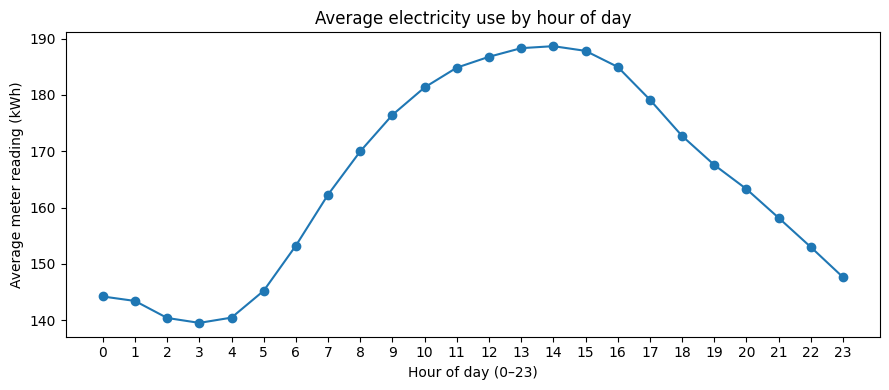

hour
0     144.199997
1     143.399994
2     140.399994
3     139.600006
4     140.500000
5     145.199997
6     153.300003
7     162.300003
8     170.000000
9     176.500000
10    181.300003
11    184.800003
12    186.800003
13    188.300003
14    188.600006
15    187.800003
16    185.000000
17    179.100006
18    172.699997
19    167.600006
20    163.300003
21    158.199997
22    153.000000
23    147.699997
Name: meter_reading, dtype: float32


In [ ]:
hourly = df.groupby("hour")["meter_reading"].mean()

plt.figure(figsize=(9, 4))
plt.plot(hourly.index, hourly.values, marker="o")
plt.title("Average electricity use by hour of day")
plt.xlabel("Hour of day (0–23)")
plt.ylabel("Average meter reading (kWh)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

print(hourly.round(1))

EDA Step 3 — Average electricity by day of week

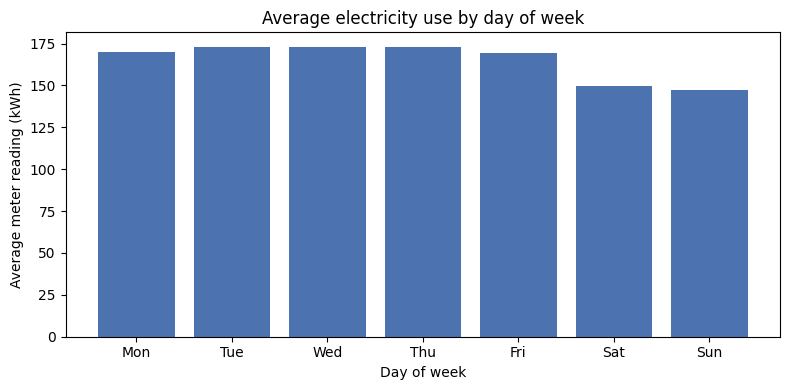

weekday
0    169.899994
1    173.100006
2    173.000000
3    172.800003
4    169.199997
5    149.800003
6    147.199997
Name: meter_reading, dtype: float32


In [ ]:
dow = df.groupby("weekday")["meter_reading"].mean()
labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(8, 4))
plt.bar(labels, dow.values, color="#4C72B0")
plt.title("Average electricity use by day of week")
plt.xlabel("Day of week")
plt.ylabel("Average meter reading (kWh)")
plt.tight_layout()
plt.show()

print(dow.round(1))

EDA Step 4 — Average electricity by month (seasonality)

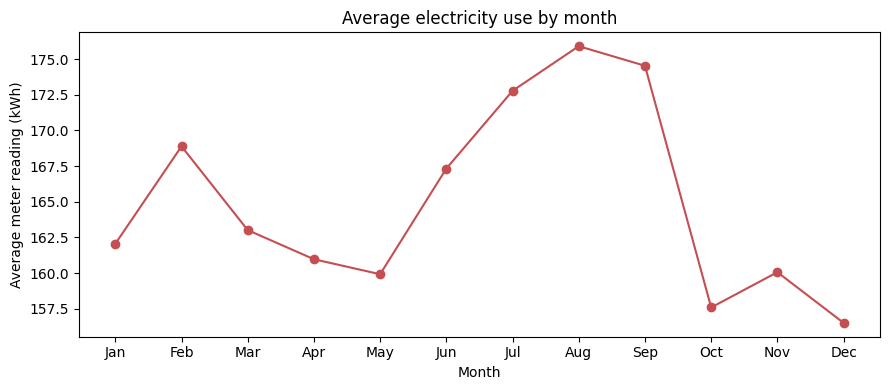

month
1     162.100006
2     168.899994
3     163.000000
4     161.000000
5     159.899994
6     167.300003
7     172.800003
8     175.899994
9     174.500000
10    157.600006
11    160.100006
12    156.500000
Name: meter_reading, dtype: float32


In [ ]:
monthly = df.groupby("month")["meter_reading"].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(9, 4))
plt.plot(range(1, 13), monthly.values, marker="o", color="#C44E52")
plt.title("Average electricity use by month")
plt.xlabel("Month")
plt.ylabel("Average meter reading (kWh)")
plt.xticks(range(1, 13), month_labels)
plt.tight_layout()
plt.show()

print(monthly.round(1))

EDA Step 5 — Which building types use the most

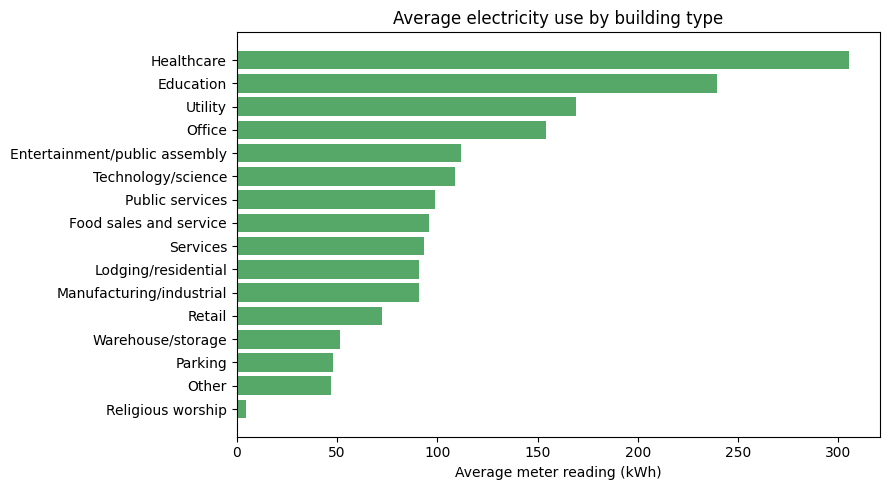

primary_use
Healthcare                       305.500000
Education                        239.199997
Utility                          169.300003
Office                           154.100006
Entertainment/public assembly    111.800003
Technology/science               109.000000
Public services                   99.000000
Food sales and service            95.900002
Services                          93.300003
Lodging/residential               90.699997
Manufacturing/industrial          90.699997
Retail                            72.500000
Warehouse/storage                 51.599998
Parking                           48.099998
Other                             46.900002
Religious worship                  4.600000
Name: meter_reading, dtype: float32


In [ ]:
by_use = (df.groupby("primary_use", observed=True)["meter_reading"]
            .mean().sort_values(ascending=False))

plt.figure(figsize=(9, 5))
plt.barh(by_use.index, by_use.values, color="#55A868")
plt.gca().invert_yaxis()   # biggest at top
plt.title("Average electricity use by building type")
plt.xlabel("Average meter reading (kWh)")
plt.tight_layout()
plt.show()

print(by_use.round(1))

EDA Step 6 — Does temperature drive energy

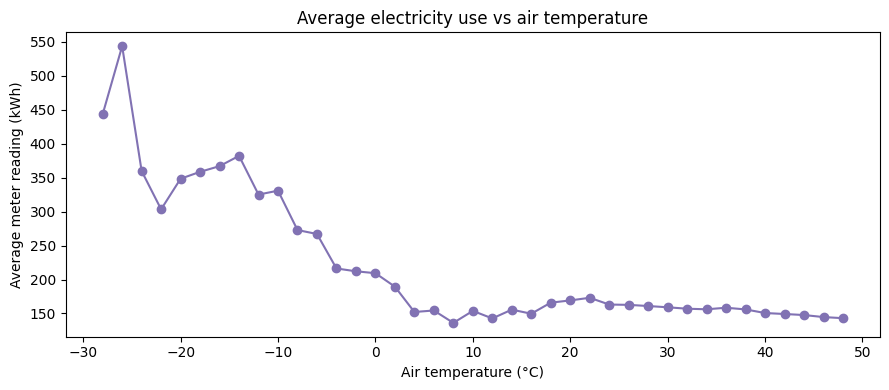

temp_bin
-28.0    443.299988
-26.0    543.500000
-24.0    359.799988
-22.0    303.299988
-20.0    348.399994
-18.0    358.500000
-16.0    366.899994
-14.0    382.100006
-12.0    325.000000
-10.0    330.799988
-8.0     272.799988
-6.0     267.000000
-4.0     216.300003
-2.0     212.100006
 0.0     209.300003
 2.0     189.500000
 4.0     152.199997
 6.0     154.399994
 8.0     136.199997
 10.0    153.800003
 12.0    142.699997
 14.0    155.699997
 16.0    149.600006
 18.0    166.000000
 20.0    169.199997
 22.0    173.100006
 24.0    163.199997
 26.0    162.699997
 28.0    161.000000
 30.0    159.100006
 32.0    157.000000
 34.0    156.199997
 36.0    158.500000
 38.0    156.000000
 40.0    150.699997
 42.0    149.300003
 44.0    147.699997
 46.0    144.699997
 48.0    143.100006
Name: meter_reading, dtype: float32


In [ ]:
# EDA Step 6: electricity vs air temperature
tmp = df[["air_temperature", "meter_reading"]].dropna().copy()

# group temperature into 2°C bins, average energy in each bin
tmp["temp_bin"] = (tmp["air_temperature"] / 2).round() * 2
temp_curve = tmp.groupby("temp_bin")["meter_reading"].mean()

plt.figure(figsize=(9, 4))
plt.plot(temp_curve.index, temp_curve.values, marker="o", color="#8172B3")
plt.title("Average electricity use vs air temperature")
plt.xlabel("Air temperature (°C)")
plt.ylabel("Average meter reading (kWh)")
plt.tight_layout()
plt.show()

print(temp_curve.round(1))

EDA Step 7 — Target distribution

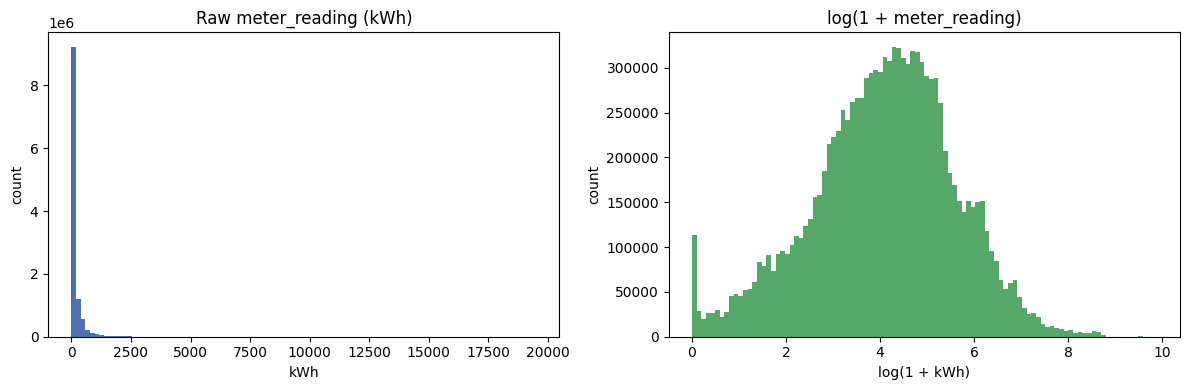

skewness raw   : 9.49
skewness log1p : -0.26


In [ ]:
# EDA Step 7: distribution of the target (meter_reading), raw vs log
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: raw kWh — expect a huge spike near 0 and a long tail
axes[0].hist(df["meter_reading"], bins=100, color="#4C72B0")
axes[0].set_title("Raw meter_reading (kWh)")
axes[0].set_xlabel("kWh"); axes[0].set_ylabel("count")

# right: log1p(kWh) = log(1 + kWh) — should look much more bell-shaped
axes[1].hist(np.log1p(df["meter_reading"]), bins=100, color="#55A868")
axes[1].set_title("log(1 + meter_reading)")
axes[1].set_xlabel("log(1 + kWh)"); axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

print("skewness raw   :", round(df["meter_reading"].skew(), 2))
print("skewness log1p :", round(np.log1p(df["meter_reading"]).skew(), 2))

EDA Step 8 — One building's yearly time series

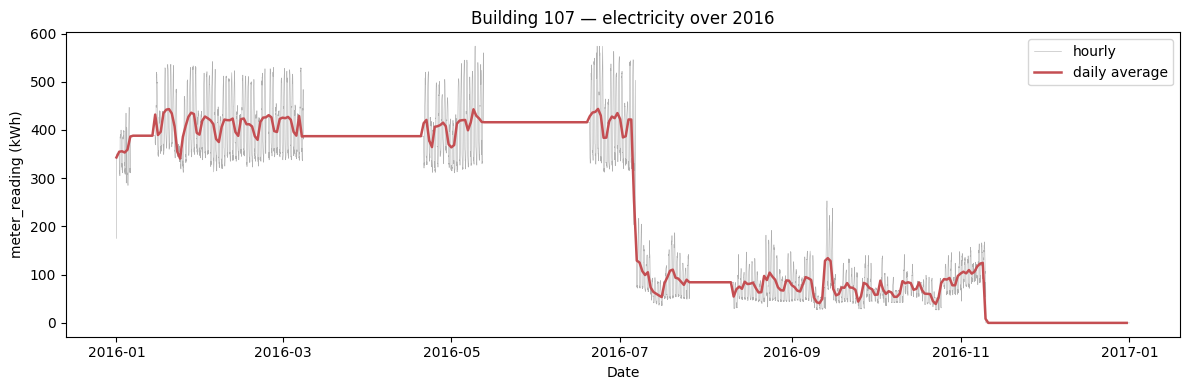

building_id 107: Education, 97,532 sq ft, 8,784 readings


In [ ]:
# auto-pick a "nice" building: near-full-year data and a decent average load
stats = df.groupby("building_id")["meter_reading"].agg(["count", "mean"])
candidates = stats[(stats["count"] > 8000) & (stats["mean"].between(100, 400))]
bid = candidates.index[0]      # first qualifying building

one = df[df["building_id"] == bid].sort_values("timestamp")
daily = one.set_index("timestamp")["meter_reading"].resample("D").mean()  # daily avg

plt.figure(figsize=(12, 4))
plt.plot(one["timestamp"], one["meter_reading"], color="#B0B0B0",
         linewidth=0.4, label="hourly")
plt.plot(daily.index, daily.values, color="#C44E52",
         linewidth=1.8, label="daily average")
plt.title(f"Building {bid} — electricity over 2016")
plt.xlabel("Date"); plt.ylabel("meter_reading (kWh)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"building_id {bid}: {one['primary_use'].iloc[0]}, "
      f"{one['square_feet'].iloc[0]:,} sq ft, {len(one):,} readings")